In [ ]:
import os
import torch
import pickle
from torch.utils.data import Dataset
import matplotlib.pyplot as plt
from rdkit import Chem
import json
import pandas as pd
import argparse
import sys
import random
import csv
import numpy as np
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split
from rdkit.RDLogger import DisableLog
from CBTokenizer import CBTokenizer

# RDKit log banned
DisableLog('rdApp.*')


#set random seed
def set_seed(seed):
    """Set all possible random seeds for reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


# check molecule SMILES
def checkmol(pre_data):
    mols = pre_data.squence
    labels = pre_data.labels
    print('Original {} has {} data, start checking'.format(pre_data.args.dataset, len(mols)))

    valid_mols = []  
    valid_labels = []  

    for i in range(len(mols)):
        if mols[i] == "":
            continue
        mol = Chem.MolFromSmiles(mols[i])
        if mol is not None:
            # rdkit 检测分子正确性
            mol = Chem.MolToSmiles(mol, canonical=True, kekuleSmiles=False)
            valid_mols.append(mol)
            valid_labels.append(int(labels[i]))

    # 提取表达式和标签
    data = [[mol, label] for mol, label in zip(valid_mols, valid_labels)]
    print('Finish checking molecules, now {} has {} data'.format(pre_data.args.dataset, len(data)))
    return data



# split data
def data_split(post_data,args,status=False):
    '''status: get detail or not
    '''
    labels = [label for input_ids, attention_mask, label in post_data]

    train_val_data, test_data, train_val_labels, test_labels = train_test_split(
        post_data, labels, test_size=0.1, stratify=labels, random_state=args.seed
    )

    train_data, val_data, train_labels, val_labels = train_test_split(
        train_val_data, train_val_labels, test_size=1/9, stratify=train_val_labels, random_state=args.seed
    )
    
    if status == True:
        def count_class_distribution(data):
            counts = {0: 0, 1: 0}
            for _, label in data:
                counts[label] += 1
            return counts
        train_distribution = count_class_distribution(train_data)
        val_distribution = count_class_distribution(val_data)
        test_distribution = count_class_distribution(test_data)

        print("Train set class distribution:", train_distribution)
        print("Validation set class distribution:", val_distribution)
        print("Test set class distribution:", test_distribution)
    return train_data,val_data,test_data


# args to select dataset and seed
def create_args(dataset,name='modelname',seed=42):

    sys.argv = sys.argv[:1] + [arg for arg in sys.argv[1:] if not arg.startswith('--f=')]

    parser = argparse.ArgumentParser(description='Process some integers.')
    parser.add_argument('--dataset', type=str, default=dataset,
                        help='The name of the dataset (BBBP, HIV, BACE, Tox21, ClinTox)')
    parser.add_argument('--name', type=str, default=name,
                        help='The name of the dataset (BBBP, HIV, BACE, Tox21, ClinTox)')
    parser.add_argument('--seed', type=int, default=seed)
    args = parser.parse_args()
    return args

# process raw data (from MolR)
class PropertyPreData():
    def __init__(self, args):
        self.args = args
        self.path = './data/data_MoIR/' + args.dataset
        self.squence = []
        self.labels = []

    def process(self):
        print('processing ' + self.args.dataset+ ' dataset')
        with open(self.path + '.csv') as f:
            for idx, line in enumerate(f.readlines()):
                if idx == 0 or line == '\n':
                    continue
                items = line.strip().split(',')
                if self.args.dataset == 'BBBP':
                    smiles, label = items[-1], items[-2]
                    # the next line is to remove unnecessary hydrogen atoms that will cause discontinuous node labels
                    smiles = smiles.replace('([H])', '').replace('[H]', '')
                elif self.args.dataset == 'HIV':
                    smiles, label = items[0], items[-1]
                    smiles = smiles.replace('se', 'Se').replace('te', 'Te')
                elif self.args.dataset == 'BACE':
                    smiles, label = items[0], items[2]
                elif self.args.dataset == 'Tox21':
                    smiles, label = items[-1], items[11]
                    smiles = smiles.replace('se', 'Se')
                    if label == '':
                        continue
                elif self.args.dataset == 'ClinTox':
                    smiles, label = items[0], items[2]
                    smiles = smiles.replace('[H]', '')
                else:
                    raise ValueError('unknown dataset')
                self.squence.append(smiles)
                self.labels.append(float(label))


# convert SMILES to token
def preprocess_and_save_data(data, save_path, tokenizer):
    #difine length of tensor =  max(len(SMILES))+2
    max_smiles_length = max(len(smiles) for smiles, _ in data)
    maxlen = max_smiles_length + 2
    processed_data = []
    failed_data = []
    for smiles, label in data:
        try:
            encoded = tokenizer.encoder(smiles, alllen = maxlen, no0mode = False)
            processed_data.append((encoded["input_ids"], encoded["attention_mask"], label))
        except Exception as e:
            #print(f"Failed to encode SMILES: {smiles}, Error: {e}")
            failed_data.append((smiles, label))
    with open(save_path, 'wb') as f:
        pickle.dump(processed_data, f)
    print(f"maxlen : {maxlen}")
    print(f"final data {len(processed_data)}")
    print(f"Data saved to {save_path}")
    if failed_data:
        failed_save_path = save_path.replace('.pkl', '_failed.csv')
        with open(failed_save_path, 'w', newline='') as f:
            writer = csv.writer(f)
            writer.writerow(['SMILES', 'Label'])
            writer.writerows(failed_data)
        print(f"Failed data saved to {failed_save_path}")

RDKit WARNING: [13:19:58] Enabling RDKit 2019.09.3 jupyter extensions
[13:19:58] Enabling RDKit 2019.09.3 jupyter extensions


## training

In [22]:
from CBmodel4prediction import *

def load_preprocessed_data(load_path):
    with open(load_path, 'rb') as f:
        data = pickle.load(f)
    print(f"Data loaded from {load_path}")
    return data

def parallel_train_test(dataset:str, pretrain_model:str, times:int): 
    accuracies = []
    aucs = []
    for i in range(2025,2025+times):
        args = create_args(dataset,'encoder_'+str(dataset)+str(i),i)
        #train_encoder_model(args,pretrain_model=pretrain_model)
        acc, auc = test_encoder_model(args, pretrain_model=pretrain_model)
        accuracies.append(acc)
        aucs.append(auc)
    # 输出平均性能
    mean_acc = np.mean(accuracies)
    mean_auc = np.mean(aucs)
    std_acc = np.std(accuracies)   
    std_auc = np.std(aucs)

    print("\n=== Final Results ===")
    print(f"Average Accuracy across folds: {mean_acc:.4f} ± {std_acc:.4f}")
    print(f"Average AUC across folds: {mean_auc:.4f} ± {std_auc:.4f}")
    return {
        "accuracies": accuracies,
        "aucs": aucs,
        "mean_accuracy": mean_acc,
        "mean_auc": mean_auc,
        "var_accuracy": std_acc,
        "var_auc": std_auc
    }
        


def train_encoder_model(args, pretrain_model='model_1200'):
    set_seed(args.seed)
    preprocess_save_path = f"./preprocessed_data/{args.dataset}.pkl"
    preprocessed_data = load_preprocessed_data(preprocess_save_path)

    train_data,val_data,test_data = data_split(preprocessed_data,args,status=False)
    #data = train_data + val_data
    
    print('train:val:test = {}:{}:{}'.format(len(train_data),len(val_data),len(test_data)))
   
    # 实例化新模型
    c = MolProperty_encoder_only(
        out_type=2,
        name=args.name,
        pre_model=pretrain_model,
        device="cuda:1",
        epoch_stop=5
    )
    print('start tarining!')
    c.batchtrain(train_data,val_data, epoch=50, batch_size=4)
    print('finish tarining!!!')

def test_encoder_model(args, pretrain_model='model_1200'):
    # 实例化新模型
    c = MolProperty_encoder_only(
        out_type=2,
        name=args.name,
        pre_model=pretrain_model,
        device="cuda:1"
    )
    set_seed(args.seed)

    preprocess_save_path = f"./preprocessed_data/{args.dataset}.pkl"
    preprocessed_data = load_preprocessed_data(preprocess_save_path)

    _, _, test_data = data_split(preprocessed_data, args)
    acc, auc = c.test(test_data)
    return acc, auc



# 平行实验

## ClinTox

In [ ]:
# BCEWithLogitsLoss()
parallel_train_test('ClinTox', pretrain_model='model_1200', times=3)

Fine-tuned model loaded from checkpoints_test/encoder_ClinTox2025.pth
Data loaded from ./preprocessed_data/ClinTox.pkl
Fine-tuned model loaded from checkpoints_test/encoder_ClinTox2026.pth
Data loaded from ./preprocessed_data/ClinTox.pkl
Fine-tuned model loaded from checkpoints_test/encoder_ClinTox2027.pth
Data loaded from ./preprocessed_data/ClinTox.pkl

=== Final Results ===
Average Accuracy across folds: 0.9099 ± 0.0115
Average AUC across folds: 0.8598 ± 0.0140


{'accuracies': [0.8986486486486487, 0.9256756756756757, 0.9054054054054054],
 'aucs': [0.8457199734571997, 0.8788984737889847, 0.8546781685467816],
 'mean_accuracy': 0.9099099099099099,
 'mean_auc': 0.8597655385976554,
 'var_accuracy': 0.011484278183767517,
 'var_auc': 0.014014616693354087}

Data loaded from ./preprocessed_data/ClinTox.pkl
train:val:test = 1180:148:148
Pre-trained model loaded from ChemBart_model/model_1200.pth
start tarining!
Epoch 0
Train Loss: 21.876449539224268, Train Acc: 0.21694915254237288
Validation Acc: 0.16891891891891891, Val Count: 148
Model saved!
Epoch 1
Train Loss: 18.97696593499859, Train Acc: 0.24491525423728813
Validation Acc: 0.28378378378378377, Val Count: 148
Model saved!
Epoch 2
Train Loss: 17.493355830956716, Train Acc: 0.30677966101694915
Validation Acc: 0.39864864864864863, Val Count: 148
Model saved!
Epoch 3
Train Loss: 16.482129968237132, Train Acc: 0.3423728813559322
Validation Acc: 0.32432432432432434, Val Count: 148
Epoch 4
Train Loss: 14.932213987864088, Train Acc: 0.373728813559322
Validation Acc: 0.3918918918918919, Val Count: 148
Epoch 5
Train Loss: 13.49901013460476, Train Acc: 0.39322033898305087
Validation Acc: 0.5608108108108109, Val Count: 148
Model saved!
Epoch 6
Train Loss: 11.902141237136675, Train Acc: 0.440677966

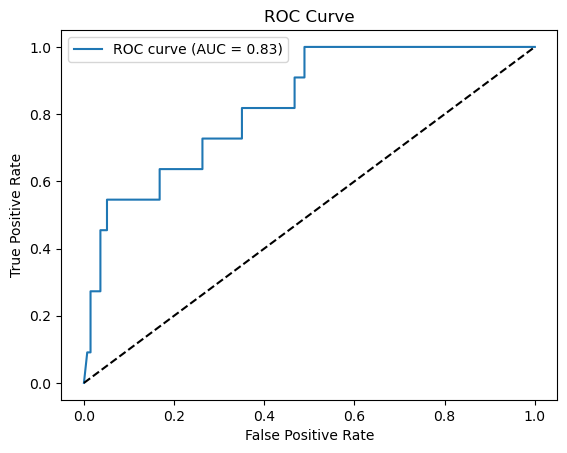

Test Accuracy: 0.5337837837837838, AUC: 0.8278035832780359
Data loaded from ./preprocessed_data/ClinTox.pkl
train:val:test = 1180:148:148
Pre-trained model loaded from ChemBart_model/model_1200.pth
start tarining!
Epoch 0
Train Loss: 23.420175295264926, Train Acc: 0.25508474576271184
Validation Acc: 0.20945945945945946, Val Count: 148
Model saved!
Epoch 1
Train Loss: 19.364198829309316, Train Acc: 0.22966101694915253
Validation Acc: 0.11486486486486487, Val Count: 148
Epoch 2
Train Loss: 17.359621316660196, Train Acc: 0.2923728813559322
Validation Acc: 0.2702702702702703, Val Count: 148
Model saved!
Epoch 3
Train Loss: 15.727797986241058, Train Acc: 0.35084745762711866
Validation Acc: 0.2635135135135135, Val Count: 148
Epoch 4
Train Loss: 14.528394554421538, Train Acc: 0.3686440677966102
Validation Acc: 0.34459459459459457, Val Count: 148
Model saved!
Epoch 5
Train Loss: 13.196022623189492, Train Acc: 0.3940677966101695
Validation Acc: 0.41216216216216217, Val Count: 148
Model saved!
E

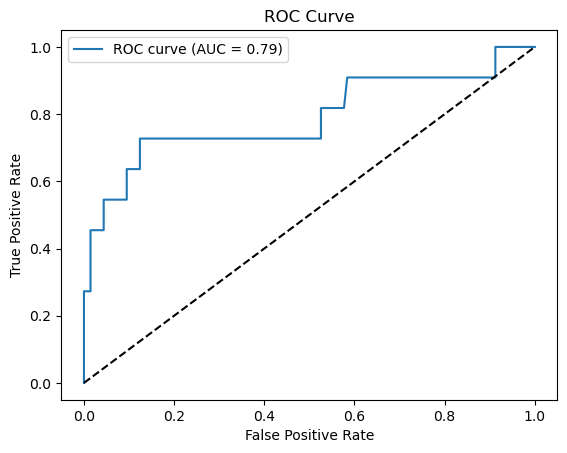

Test Accuracy: 0.6756756756756757, AUC: 0.789980092899801
Data loaded from ./preprocessed_data/ClinTox.pkl
train:val:test = 1180:148:148
Pre-trained model loaded from ChemBart_model/model_1200.pth
start tarining!
Epoch 0
Train Loss: 28.668618125782814, Train Acc: 0.32457627118644067
Validation Acc: 0.14189189189189189, Val Count: 148
Model saved!
Epoch 1
Train Loss: 19.31899226445239, Train Acc: 0.2483050847457627
Validation Acc: 0.10810810810810811, Val Count: 148
Epoch 2
Train Loss: 17.83594598574564, Train Acc: 0.28135593220338984
Validation Acc: 0.2905405405405405, Val Count: 148
Model saved!
Epoch 3
Train Loss: 16.36826741162804, Train Acc: 0.34067796610169493
Validation Acc: 0.2972972972972973, Val Count: 148
Model saved!
Epoch 4
Train Loss: 15.079059035109822, Train Acc: 0.36271186440677966
Validation Acc: 0.2972972972972973, Val Count: 148
Epoch 5
Train Loss: 14.059502388336114, Train Acc: 0.38813559322033897
Validation Acc: 0.30405405405405406, Val Count: 148
Model saved!
Epoc

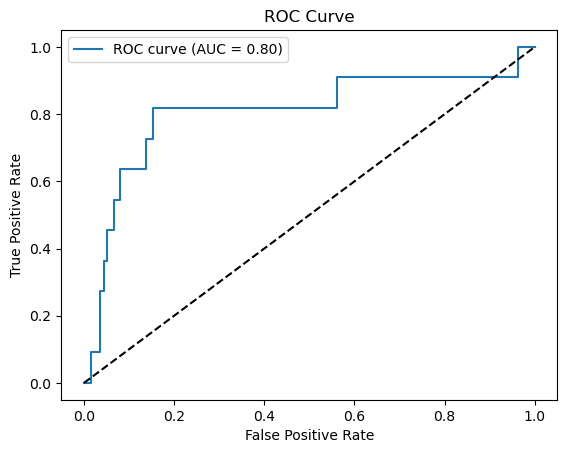

Test Accuracy: 0.4797297297297297, AUC: 0.8049104180491041


In [ ]:
# MSEloss
for i in range(2025,2028):
    args = create_args('ClinTox','encoder_ClinTox'+str(i),i)
    train_encoder_model(args,pretrain_model='model_1200')
    test_encoder_model(args)

## BACE

In [23]:
#BCEWithLogitsLoss

parallel_train_test('BACE', pretrain_model='model_1200', times=3)

Fine-tuned model loaded from checkpoints_test/encoder_BACE2025.pth
Data loaded from ./preprocessed_data/BACE.pkl
Fine-tuned model loaded from checkpoints_test/encoder_BACE2026.pth
Data loaded from ./preprocessed_data/BACE.pkl
Fine-tuned model loaded from checkpoints_test/encoder_BACE2027.pth
Data loaded from ./preprocessed_data/BACE.pkl

=== Final Results ===
Average Accuracy across folds: 0.7522 ± 0.0636
Average AUC across folds: 0.8732 ± 0.0214


{'accuracies': [0.8421052631578947, 0.7105263157894737, 0.7039473684210527],
 'aucs': [0.8954077178278331, 0.8798672952680286, 0.8442465514230836],
 'mean_accuracy': 0.7521929824561404,
 'mean_auc': 0.8731738548396485,
 'var_accuracy': 0.06363429003748641,
 'var_auc': 0.02141600407094072}

Data loaded from ./preprocessed_data/BACE.pkl
train:val:test = 1209:152:152
Pre-trained model loaded from ChemBart_model/model_1200.pth
start tarining!
Epoch 0
Train Loss: 80.07097175251693, Train Acc: 0.46153846153846156
Validation Acc: 0.45394736842105265, Val Count: 152
Model saved!
Epoch 1
Train Loss: 60.78907882794738, Train Acc: 0.45905707196029777
Validation Acc: 0.45394736842105265, Val Count: 152
Epoch 2
Train Loss: 51.136333933100104, Train Acc: 0.47973531844499584
Validation Acc: 0.47368421052631576, Val Count: 152
Model saved!
Epoch 3
Train Loss: 46.66407058387995, Train Acc: 0.5260545905707196
Validation Acc: 0.4934210526315789, Val Count: 152
Model saved!
Epoch 4
Train Loss: 41.65509019466117, Train Acc: 0.5194375516956162
Validation Acc: 0.5, Val Count: 152
Model saved!
Epoch 5
Train Loss: 39.31113145779818, Train Acc: 0.543424317617866
Validation Acc: 0.5394736842105263, Val Count: 152
Model saved!
Epoch 6
Train Loss: 37.066059491131455, Train Acc: 0.5459057071960298
Va

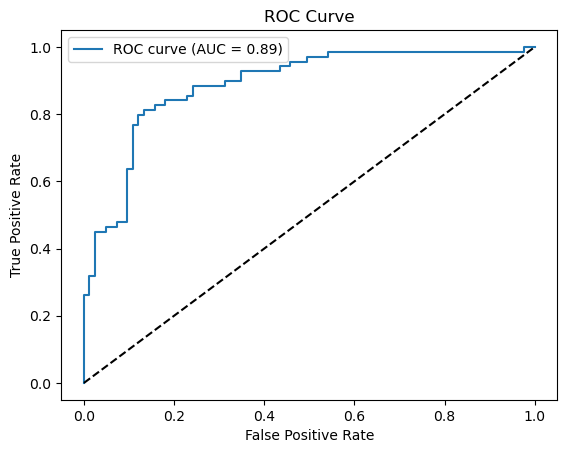

Test Accuracy: 0.6381578947368421, AUC: 0.8875502008032128
Data loaded from ./preprocessed_data/BACE.pkl
train:val:test = 1209:152:152
Pre-trained model loaded from ChemBart_model/model_1200.pth
start tarining!
Epoch 0
Train Loss: 85.51238603517413, Train Acc: 0.4640198511166253
Validation Acc: 0.45394736842105265, Val Count: 152
Model saved!
Epoch 1
Train Loss: 60.05244752764702, Train Acc: 0.45822994210090984
Validation Acc: 0.45394736842105265, Val Count: 152
Epoch 2
Train Loss: 50.608718076720834, Train Acc: 0.48221670802315963
Validation Acc: 0.5328947368421053, Val Count: 152
Model saved!
Epoch 3
Train Loss: 45.69060628116131, Train Acc: 0.511166253101737
Validation Acc: 0.4868421052631579, Val Count: 152
Epoch 4
Train Loss: 41.009251217357814, Train Acc: 0.5268817204301075
Validation Acc: 0.618421052631579, Val Count: 152
Model saved!
Epoch 5
Train Loss: 38.6572102336213, Train Acc: 0.5665839536807279
Validation Acc: 0.5263157894736842, Val Count: 152
Epoch 6
Train Loss: 36.6241

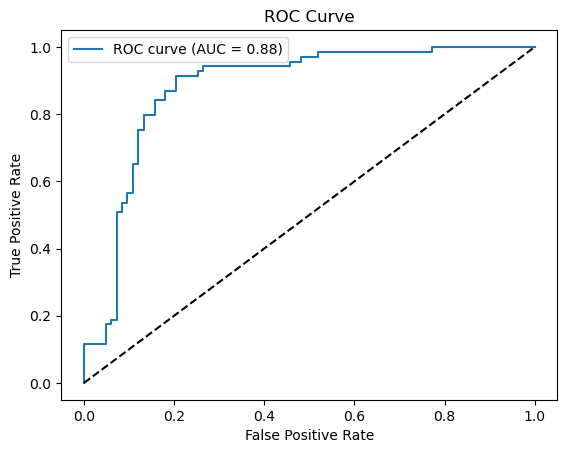

Test Accuracy: 0.7105263157894737, AUC: 0.8798672952680286
Data loaded from ./preprocessed_data/BACE.pkl
train:val:test = 1209:152:152
Pre-trained model loaded from ChemBart_model/model_1200.pth
start tarining!
Epoch 0
Train Loss: 96.14282273501158, Train Acc: 0.46898263027295284
Validation Acc: 0.45394736842105265, Val Count: 152
Model saved!
Epoch 1
Train Loss: 55.83127902448177, Train Acc: 0.46567411083540117
Validation Acc: 0.4934210526315789, Val Count: 152
Model saved!
Epoch 2
Train Loss: 48.19713941309601, Train Acc: 0.5045492142266336
Validation Acc: 0.5131578947368421, Val Count: 152
Model saved!
Epoch 3
Train Loss: 44.28311443235725, Train Acc: 0.5310173697270472
Validation Acc: 0.5723684210526315, Val Count: 152
Model saved!
Epoch 4
Train Loss: 40.41089603753062, Train Acc: 0.5351530190239868
Validation Acc: 0.5394736842105263, Val Count: 152
Epoch 5
Train Loss: 38.63460994372144, Train Acc: 0.543424317617866
Validation Acc: 0.5460526315789473, Val Count: 152
Epoch 6
Train L

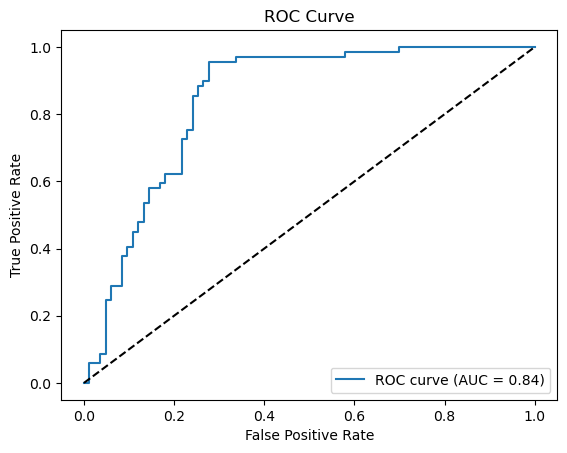

Test Accuracy: 0.7039473684210527, AUC: 0.8442465514230836


In [ ]:
# MSEloss
for i in range(2025,2028):
    args = create_args('BACE','encoder_BACE'+str(i),i)
    train_encoder_model(args,pretrain_model='model_1200')
    test_encoder_model(args)

## BBBP

In [24]:
#BCEWithLogitsLoss
parallel_train_test('BBBP', pretrain_model='model_1200', times=3)

Fine-tuned model loaded from checkpoints_test/encoder_BBBP2025.pth
Data loaded from ./preprocessed_data/BBBP.pkl
Fine-tuned model loaded from checkpoints_test/encoder_BBBP2026.pth
Data loaded from ./preprocessed_data/BBBP.pkl
Fine-tuned model loaded from checkpoints_test/encoder_BBBP2027.pth
Data loaded from ./preprocessed_data/BBBP.pkl

=== Final Results ===
Average Accuracy across folds: 0.8366 ± 0.0023
Average AUC across folds: 0.8882 ± 0.0076


{'accuracies': [0.8333333333333334, 0.8382352941176471, 0.8382352941176471],
 'aucs': [0.8886885683760684, 0.8973023504273504, 0.8787393162393163],
 'mean_accuracy': 0.8366013071895425,
 'mean_auc': 0.8882434116809117,
 'var_accuracy': 0.0023108064744658333,
 'var_auc': 0.0075848613667384625}

Data loaded from ./preprocessed_data/BBBP.pkl
train:val:test = 1631:204:204
Pre-trained model loaded from ChemBart_model/model_1200.pth
start tarining!
Epoch 0
Train Loss: 93.43711044173688, Train Acc: 0.7320662170447578
Validation Acc: 0.7647058823529411, Val Count: 204
Model saved!
Epoch 1
Train Loss: 45.87770770676434, Train Acc: 0.7682403433476395
Validation Acc: 0.7647058823529411, Val Count: 204
Epoch 2
Train Loss: 40.09248625545297, Train Acc: 0.7725321888412017
Validation Acc: 0.7647058823529411, Val Count: 204
Epoch 3
Train Loss: 36.12226762820501, Train Acc: 0.7823421213979154
Validation Acc: 0.7647058823529411, Val Count: 204
Epoch 4
Train Loss: 32.227527783077676, Train Acc: 0.7872470876762723
Validation Acc: 0.7696078431372549, Val Count: 204
Model saved!
Epoch 5
Train Loss: 28.85874838003656, Train Acc: 0.7903126916002452
Validation Acc: 0.7696078431372549, Val Count: 204
Epoch 6
Train Loss: 25.59407869845745, Train Acc: 0.8044144696505211
Validation Acc: 0.77941176470588

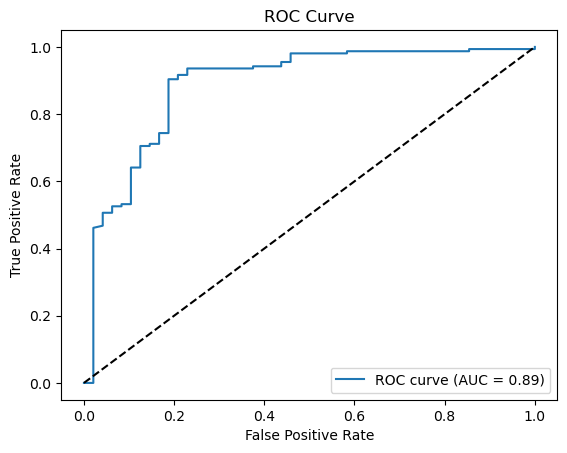

Test Accuracy: 0.8333333333333334, AUC: 0.8886885683760684
Data loaded from ./preprocessed_data/BBBP.pkl
train:val:test = 1631:204:204
Pre-trained model loaded from ChemBart_model/model_1200.pth
start tarining!
Epoch 0
Train Loss: 98.81629004189745, Train Acc: 0.730226854690374
Validation Acc: 0.7647058823529411, Val Count: 204
Model saved!
Epoch 1
Train Loss: 48.142097174422815, Train Acc: 0.765787860208461
Validation Acc: 0.7696078431372549, Val Count: 204
Model saved!
Epoch 2
Train Loss: 42.38377340513398, Train Acc: 0.7719190680564071
Validation Acc: 0.7745098039215687, Val Count: 204
Model saved!
Epoch 3
Train Loss: 37.98045466700569, Train Acc: 0.7792765174739423
Validation Acc: 0.7794117647058824, Val Count: 204
Model saved!
Epoch 4
Train Loss: 34.27566724526696, Train Acc: 0.7847946045370938
Validation Acc: 0.7794117647058824, Val Count: 204
Epoch 5
Train Loss: 30.38944364374038, Train Acc: 0.7854077253218884
Validation Acc: 0.7990196078431373, Val Count: 204
Model saved!
Epoch

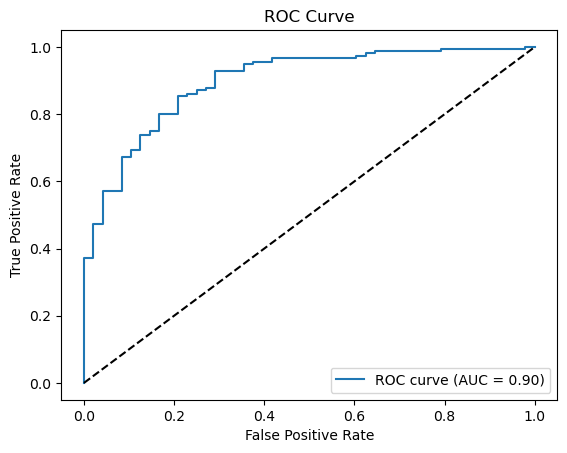

Test Accuracy: 0.8382352941176471, AUC: 0.8973023504273504
Data loaded from ./preprocessed_data/BBBP.pkl
train:val:test = 1631:204:204
Pre-trained model loaded from ChemBart_model/model_1200.pth
start tarining!
Epoch 0
Train Loss: 124.83275479543954, Train Acc: 0.7014101778050276
Validation Acc: 0.7647058823529411, Val Count: 204
Model saved!
Epoch 1
Train Loss: 46.22018751828, Train Acc: 0.765787860208461
Validation Acc: 0.7647058823529411, Val Count: 204
Epoch 2
Train Loss: 41.19538026518421, Train Acc: 0.7731453096259964
Validation Acc: 0.7647058823529411, Val Count: 204
Epoch 3
Train Loss: 37.52713658014545, Train Acc: 0.7811158798283262
Validation Acc: 0.7843137254901961, Val Count: 204
Model saved!
Epoch 4
Train Loss: 34.58412174929981, Train Acc: 0.7878602084610669
Validation Acc: 0.7941176470588235, Val Count: 204
Model saved!
Epoch 5
Train Loss: 31.151944448865834, Train Acc: 0.7976701410177806
Validation Acc: 0.7843137254901961, Val Count: 204
Epoch 6
Train Loss: 28.227610796

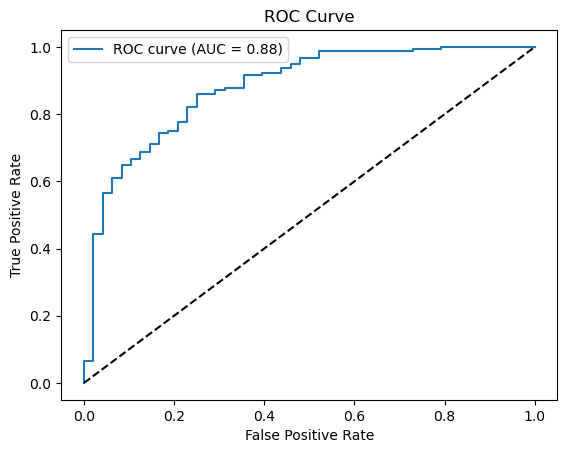

Test Accuracy: 0.8382352941176471, AUC: 0.8787393162393163


In [ ]:
# MSEloss
for i in range(2025,2028):
    args = create_args('BBBP','encoder_BBBP'+str(i),i)
    train_encoder_model(args,pretrain_model='model_1200')
    test_encoder_model(args)

## Tox21

In [ ]:
#MSEloss
parallel_train_test('Tox21', pretrain_model='model_1200', times=3)

Fine-tuned model loaded from checkpoints_test/encoder_Tox212025.pth
Data loaded from ./preprocessed_data/Tox21.pkl
Fine-tuned model loaded from checkpoints_test/encoder_Tox212026.pth
Data loaded from ./preprocessed_data/Tox21.pkl
Fine-tuned model loaded from checkpoints_test/encoder_Tox212027.pth
Data loaded from ./preprocessed_data/Tox21.pkl

=== Final Results ===
Average Accuracy across folds: 0.5263 ± 0.0741
Average AUC across folds: 0.8243 ± 0.0396


{'accuracies': [0.4312590448625181, 0.5354558610709117, 0.6121562952243126],
 'aucs': [0.8727749066896354, 0.7758756818834337, 0.8243252942865346],
 'mean_accuracy': 0.5262904003859141,
 'mean_auc': 0.8243252942865346,
 'var_accuracy': 0.07413482334814328,
 'var_auc': 0.0395589428744054}

Data loaded from ./preprocessed_data/Tox21.pkl
train:val:test = 5527:691:691
Pre-trained model loaded from ChemBart_model/model_1200.pth
start tarining!
Epoch 0
Train Loss: 79.90295070502907, Train Acc: 0.2554731318979555
Validation Acc: 0.23299565846599132, Val Count: 691
Model saved!
Epoch 1
Train Loss: 73.62867264801753, Train Acc: 0.28406006875339246
Validation Acc: 0.13603473227206947, Val Count: 691
Epoch 2
Train Loss: 70.1903305347223, Train Acc: 0.303781436584042
Validation Acc: 0.11287988422575977, Val Count: 691
Epoch 3
Train Loss: 65.31913053936296, Train Acc: 0.34213859236475486
Validation Acc: 0.45007235890014474, Val Count: 691
Model saved!
Epoch 4
Train Loss: 60.56376399207511, Train Acc: 0.370001809299801
Validation Acc: 0.1345875542691751, Val Count: 691
Epoch 5
Train Loss: 54.9659883716522, Train Acc: 0.39279898679211145
Validation Acc: 0.23444283646888567, Val Count: 691
Epoch 6
Train Loss: 49.52086339510424, Train Acc: 0.41686267414510586
Validation Acc: 0.186685962

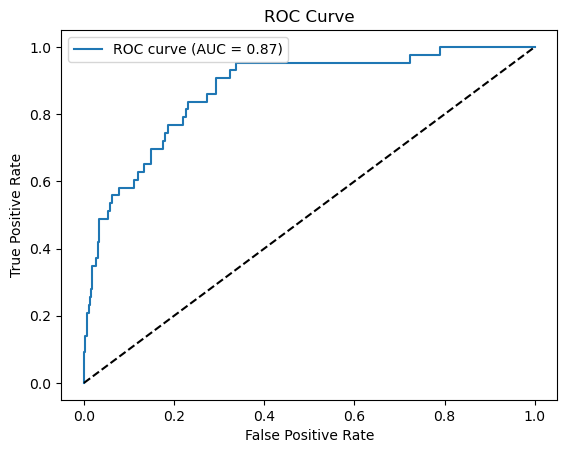

Test Accuracy: 0.4312590448625181, AUC: 0.8727749066896354
Data loaded from ./preprocessed_data/Tox21.pkl
train:val:test = 5527:691:691
Pre-trained model loaded from ChemBart_model/model_1200.pth
start tarining!
Epoch 0
Train Loss: 81.31372085862677, Train Acc: 0.2710331101863579
Validation Acc: 0.18234442836468887, Val Count: 691
Model saved!
Epoch 1
Train Loss: 73.24040469276224, Train Acc: 0.2958205174597431
Validation Acc: 0.27496382054992763, Val Count: 691
Model saved!
Epoch 2
Train Loss: 69.38810654629378, Train Acc: 0.31572281527049034
Validation Acc: 0.17800289435600578, Val Count: 691
Epoch 3
Train Loss: 64.89779049875779, Train Acc: 0.3388818527229962
Validation Acc: 0.4196816208393632, Val Count: 691
Model saved!
Epoch 4
Train Loss: 60.276045609643916, Train Acc: 0.3645739098968699
Validation Acc: 0.2894356005788712, Val Count: 691
Epoch 5
Train Loss: 53.77181237334298, Train Acc: 0.3984078161751402
Validation Acc: 0.36324167872648333, Val Count: 691
Epoch 6
Train Loss: 47.

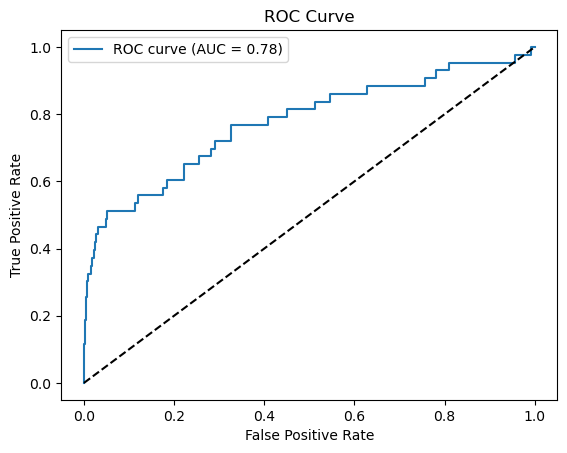

Test Accuracy: 0.5354558610709117, AUC: 0.7758756818834337
Data loaded from ./preprocessed_data/Tox21.pkl
train:val:test = 5527:691:691
Pre-trained model loaded from ChemBart_model/model_1200.pth
start tarining!
Epoch 0
Train Loss: 89.68696297821589, Train Acc: 0.2793558892708522
Validation Acc: 0.28509406657018815, Val Count: 691
Model saved!
Epoch 1
Train Loss: 74.25900720187201, Train Acc: 0.29129726795730054
Validation Acc: 0.23299565846599132, Val Count: 691
Epoch 2
Train Loss: 71.18555252419901, Train Acc: 0.3041432965442374
Validation Acc: 0.36034732272069464, Val Count: 691
Model saved!
Epoch 3
Train Loss: 65.67325215079472, Train Acc: 0.3363488330016284
Validation Acc: 0.3921852387843705, Val Count: 691
Model saved!
Epoch 4
Train Loss: 59.96969315967726, Train Acc: 0.37868644834449067
Validation Acc: 0.20694645441389292, Val Count: 691
Epoch 5
Train Loss: 55.30786745307705, Train Acc: 0.3902659670707436
Validation Acc: 0.5991316931982634, Val Count: 691
Model saved!
Epoch 6
Tr

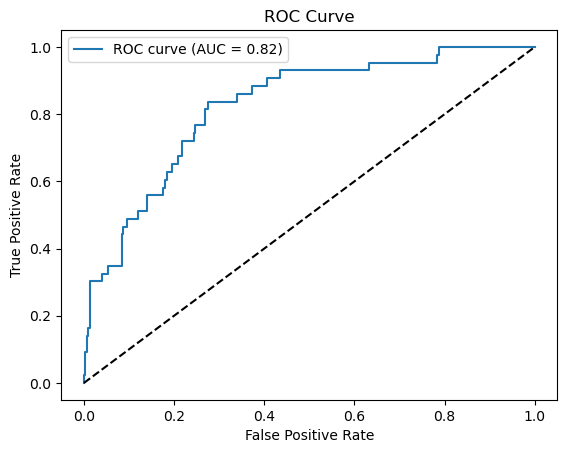

Test Accuracy: 0.6121562952243126, AUC: 0.8243252942865346


In [ ]:
# MSEloss
for i in range(2025,2028):
    args = create_args('Tox21','encoder_Tox21'+str(i),i)
    train_encoder_model(args,pretrain_model='model_1200')
    test_encoder_model(args)

## HIV

In [ ]:
#MSEloss
parallel_train_test('HIV', pretrain_model='model_1200', times=3)

Fine-tuned model loaded from checkpoints_test/encoder_HIV2025.pth
Data loaded from ./preprocessed_data/HIV.pkl
Fine-tuned model loaded from checkpoints_test/encoder_HIV2026.pth
Data loaded from ./preprocessed_data/HIV.pkl
Fine-tuned model loaded from checkpoints_test/encoder_HIV2027.pth
Data loaded from ./preprocessed_data/HIV.pkl

=== Final Results ===
Average Accuracy across folds: 0.5512 ± 0.0633
Average AUC across folds: 0.8063 ± 0.0136


{'accuracies': [0.4724045708728422, 0.5538536348164357, 0.6272793581327498],
 'aucs': [0.7934994471039444, 0.8002138098037568, 0.8251632443100698],
 'mean_accuracy': 0.5511791879406759,
 'mean_auc': 0.8062921670725903,
 'var_accuracy': 0.06325564233999924,
 'var_auc': 0.013622501818519376}

Data loaded from ./preprocessed_data/HIV.pkl
train:val:test = 32898:4113:4113
Pre-trained model loaded from ChemBart_model/model_1200.pth
start tarining!
Epoch 0
Train Loss: 259.52776084552715, Train Acc: 0.2978904492674327
Validation Acc: 0.46900072939460247, Val Count: 4113
Model saved!
Epoch 1
Train Loss: 230.92239833864733, Train Acc: 0.33032403185603987
Validation Acc: 0.1560904449307075, Val Count: 4113
Epoch 2
Train Loss: 210.87682445315477, Train Acc: 0.3568605994285367
Validation Acc: 0.17675662533430586, Val Count: 4113
Epoch 3
Train Loss: 195.1144147361083, Train Acc: 0.37236306158429083
Validation Acc: 0.12107950401167031, Val Count: 4113
Epoch 4
Train Loss: 181.51246900026945, Train Acc: 0.3822420815855067
Validation Acc: 0.21954777534646244, Val Count: 4113
Epoch 5
Train Loss: 168.47597842497635, Train Acc: 0.3949480211563013
Validation Acc: 0.4206175540967664, Val Count: 4113
No improvement in the last 5 epochs. Training stopped.
finish tarining!!!
Fine-tuned model loade

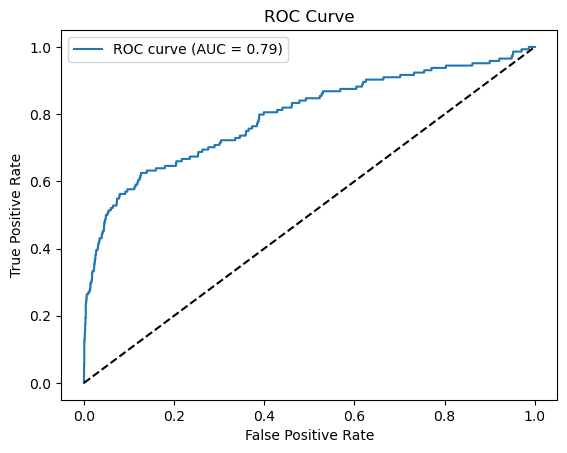

Test Accuracy: 0.4724045708728422, AUC: 0.7934994471039444
Data loaded from ./preprocessed_data/HIV.pkl
train:val:test = 32898:4113:4113
Pre-trained model loaded from ChemBart_model/model_1200.pth
start tarining!
Epoch 0
Train Loss: 261.0524015674873, Train Acc: 0.300626177883154
Validation Acc: 0.24094335035254072, Val Count: 4113
Model saved!
Epoch 1
Train Loss: 233.05920848232745, Train Acc: 0.3251869414554076
Validation Acc: 0.27182105519085825, Val Count: 4113
Model saved!
Epoch 2
Train Loss: 215.34831458124063, Train Acc: 0.3450057754270776
Validation Acc: 0.45052273279844396, Val Count: 4113
Model saved!
Epoch 3
Train Loss: 198.645840681128, Train Acc: 0.36044744361359354
Validation Acc: 0.5071723802577194, Val Count: 4113
Model saved!
Epoch 4
Train Loss: 184.53892269407788, Train Acc: 0.3775001519849231
Validation Acc: 0.24896669097982008, Val Count: 4113
Epoch 5
Train Loss: 172.2457345734265, Train Acc: 0.3929114231868199
Validation Acc: 0.3673717481157306, Val Count: 4113
Epo

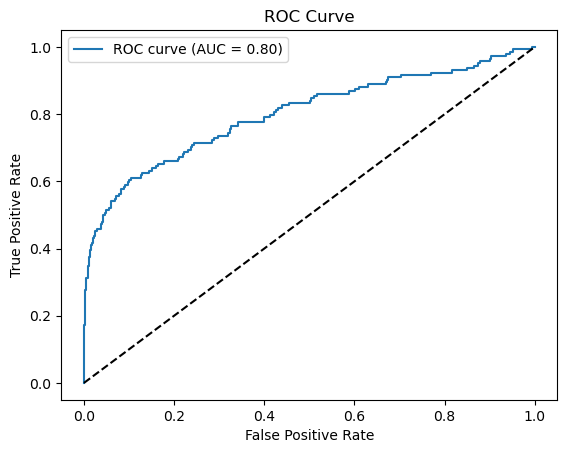

Test Accuracy: 0.5538536348164357, AUC: 0.8002138098037568
Data loaded from ./preprocessed_data/HIV.pkl
train:val:test = 32898:4113:4113
Pre-trained model loaded from ChemBart_model/model_1200.pth
start tarining!
Epoch 0
Train Loss: 268.610038249808, Train Acc: 0.3069487506839322
Validation Acc: 0.23729637734014103, Val Count: 4113
Model saved!
Epoch 1
Train Loss: 233.861332202604, Train Acc: 0.3333029363487142
Validation Acc: 0.2426452710916606, Val Count: 4113
Model saved!
Epoch 2
Train Loss: 214.8614814573266, Train Acc: 0.359109976290352
Validation Acc: 0.2574762946754194, Val Count: 4113
Model saved!
Epoch 3
Train Loss: 199.18706176977867, Train Acc: 0.37509879020001213
Validation Acc: 0.6061269146608315, Val Count: 4113
Model saved!
Epoch 4
Train Loss: 184.68107020822572, Train Acc: 0.37898960423126027
Validation Acc: 0.10041332360807197, Val Count: 4113
Epoch 5
Train Loss: 171.24569306361127, Train Acc: 0.3937625387561554
Validation Acc: 0.3508388037928519, Val Count: 4113
Epoch

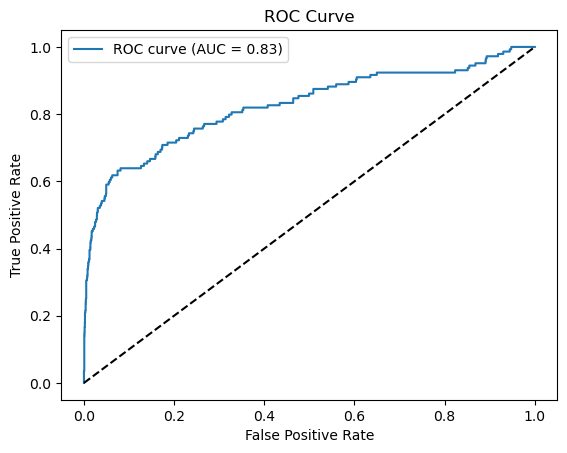

Test Accuracy: 0.6272793581327498, AUC: 0.8251632443100698


In [ ]:
# MSEloss
for i in range(2025,2028):
    args = create_args('HIV','encoder_HIV'+str(i),i)
    train_encoder_model(args,pretrain_model='model_1200')
    test_encoder_model(args)

# 交叉验证

In [ ]:
from CBmodel4prediction import *
from sklearn.model_selection import StratifiedKFold
import numpy as np

def load_preprocessed_data(load_path):
    with open(load_path, 'rb') as f:
        data = pickle.load(f)
    print(f"Data loaded from {load_path}")
    return data

def train_cv(args, pretrain_model='model_1200', n_splits=5):
    set_seed(args.seed)
    preprocess_save_path = f"./preprocessed_data/{args.dataset}.pkl"
    preprocessed_data = load_preprocessed_data(preprocess_save_path)

    # 提取标签用于分层抽样
    labels = [label for input_ids, attention_mask, label in preprocessed_data]

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=args.seed)
    
    fold = 0
    fold_accuracies = []
    fold_aucs = []

    for train_index, val_index in skf.split(np.zeros(len(labels)), labels):
        fold += 1
        print(f"\n===== Fold {fold} =====")

        train_data = [preprocessed_data[i] for i in train_index]
        val_data = [preprocessed_data[i] for i in val_index]

        print(f"Train size: {len(train_data)}, Val size: {len(val_data)}")

        # 实例化模型（每次新Fold都重新初始化）
        c = MolProperty_encoder_only(
            out_type=2,
            name=f"{args.name}_fold{fold}",
            pre_model=pretrain_model,
            device="cuda:1",
            epoch_stop=5
        )

        print('Starting training...')
        c.batchtrain(train_data, val_data, epoch=50, batch_size=4)
        print('Training finished!')

        # 评估验证集
        acc, auc = c.test(val_data)
        fold_accuracies.append(acc)
        fold_aucs.append(auc)
        print(f"Fold {fold} - Accuracy: {acc:.4f}, AUC: {auc:.4f}")

    # 输出平均性能
    mean_acc = np.mean(fold_accuracies)
    mean_auc = np.mean(fold_aucs)
    std_acc = np.std(fold_accuracies)   
    std_auc = np.std(fold_aucs)

    print("\n=== Final Results ===")
    print(f"Average Accuracy across folds: {mean_acc:.4f} ± {std_acc:.4f}")
    print(f"Average AUC across folds: {mean_auc:.4f} ± {std_auc:.4f}")

    return {
        "accuracies": fold_accuracies,
        "aucs": fold_aucs,
        "mean_accuracy": mean_acc,
        "mean_auc": mean_auc,
        "var_accuracy": std_acc,
        "var_auc": std_auc
    }



In [8]:
args = create_args('ClinTox','ClinTox',42)
train_cv(args,pretrain_model='model_1200',n_splits=5)

Data loaded from ./preprocessed_data/ClinTox.pkl

===== Fold 1 =====
Train size: 1180, Val size: 296
Fine-tuned model loaded from checkpoints_test/ClinTox_fold1.pth
Starting training...
Model saved!
Model saved!
No improvement in the last 5 epochs. Training stopped.
Training finished!
Fold 1 - Accuracy: 0.9122, AUC: 0.8261

===== Fold 2 =====
Train size: 1181, Val size: 295
Fine-tuned model loaded from checkpoints_test/ClinTox_fold2.pth
Starting training...
Model saved!
Model saved!
No improvement in the last 5 epochs. Training stopped.
Training finished!
Fold 2 - Accuracy: 0.8983, AUC: 0.9113

===== Fold 3 =====
Train size: 1181, Val size: 295
Fine-tuned model loaded from checkpoints_test/ClinTox_fold3.pth
Starting training...
Model saved!
No improvement in the last 5 epochs. Training stopped.
Training finished!
Fold 3 - Accuracy: 0.9254, AUC: 0.8877

===== Fold 4 =====
Train size: 1181, Val size: 295
Fine-tuned model loaded from checkpoints_test/ClinTox_fold4.pth
Starting training...

{'accuracies': [0.9121621621621622,
  0.8983050847457628,
  0.9254237288135593,
  0.9322033898305084,
  0.9016949152542373],
 'aucs': [0.826086956521739,
  0.9112554112554112,
  0.8876956376956378,
  0.8816183816183817,
  0.855099104859335],
 'mean_accuracy': 0.913957856161246,
 'mean_auc': 0.8723510983901009,
 'var_accuracy': 0.013137573780327608,
 'var_auc': 0.02923314929341616}

In [3]:
args = create_args('BBBP','BBBP',42)
train_cv(args,pretrain_model='model_1200',n_splits=5)

Data loaded from ./preprocessed_data/BBBP.pkl

===== Fold 1 =====
Train size: 1631, Val size: 408
Fine-tuned model loaded from checkpoints_test/BBBP_fold1.pth
Starting training...
Model saved!
No improvement in the last 5 epochs. Training stopped.
Training finished!
Fold 2 - Accuracy: 0.8652, AUC: 0.9136

===== Fold 2 =====
Train size: 1631, Val size: 408
Fine-tuned model loaded from checkpoints_test/BBBP_fold2.pth
Starting training...
Model saved!
No improvement in the last 5 epochs. Training stopped.
Training finished!
Fold 3 - Accuracy: 0.8701, AUC: 0.8849

===== Fold 3 =====
Train size: 1631, Val size: 408
Pre-trained model loaded from ChemBart_model/model_1200.pth
Starting training...
Model saved!
Model saved!
No improvement in the last 5 epochs. Training stopped.
Training finished!
Fold 4 - Accuracy: 0.8725, AUC: 0.8783

===== Fold 4 =====
Train size: 1631, Val size: 408
Pre-trained model loaded from ChemBart_model/model_1200.pth
Starting training...
Model saved!
Model saved!
No 

{'accuracies': [0.8651960784313726,
  0.8700980392156863,
  0.8725490196078431,
  0.8602941176470589,
  0.8796068796068796],
 'aucs': [0.9135783920940171,
  0.8849492521367522,
  0.8782552083333334,
  0.9130275106837608,
  0.9270242914979757],
 'mean_accuracy': 0.869548826901768,
 'mean_auc': 0.9033669309491679,
 'var_accuracy': 4.301265545877524e-05,
 'var_auc': 0.00034541619064588013}

In [6]:
args = create_args('BACE','BACE',42)
train_cv(args,pretrain_model='model_1200',n_splits=5)

Data loaded from ./preprocessed_data/BACE.pkl

===== Fold 1 =====
Train size: 1210, Val size: 303
Pre-trained model loaded from ChemBart_model/model_1200.pth
Starting training...
Model saved!
Model saved!
Model saved!
Model saved!
Model saved!
Model saved!
Model saved!
Model saved!
Model saved!
No improvement in the last 5 epochs. Training stopped.
Training finished!
Fold 1 - Accuracy: 0.7657, AUC: 0.8405

===== Fold 2 =====
Train size: 1210, Val size: 303
Pre-trained model loaded from ChemBart_model/model_1200.pth
Starting training...
Model saved!
Model saved!
Model saved!
Model saved!
Model saved!
Model saved!
Model saved!
Model saved!
Model saved!
No improvement in the last 5 epochs. Training stopped.
Training finished!
Fold 2 - Accuracy: 0.8020, AUC: 0.8758

===== Fold 3 =====
Train size: 1210, Val size: 303
Pre-trained model loaded from ChemBart_model/model_1200.pth
Starting training...
Model saved!
Model saved!
Model saved!
Model saved!
Model saved!
Model saved!
No improvement in

{'accuracies': [0.7656765676567657,
  0.801980198019802,
  0.759075907590759,
  0.7980132450331126,
  0.7947019867549668],
 'aucs': [0.8404983330408843,
  0.8758454106280192,
  0.8344751866490997,
  0.8799487451396254,
  0.8669582891481089],
 'mean_accuracy': 0.7838895810110813,
 'mean_auc': 0.8595451929211475,
 'var_accuracy': 0.017838658420345006,
 'var_auc': 0.018591633182013116}

In [7]:
args = create_args('Tox21','Tox21',42)
train_cv(args,pretrain_model='model_1200',n_splits=5)

Data loaded from ./preprocessed_data/Tox21.pkl

===== Fold 1 =====
Train size: 5527, Val size: 1382
Pre-trained model loaded from ChemBart_model/model_1200.pth
Starting training...
Model saved!
Model saved!
Model saved!
Model saved!
No improvement in the last 5 epochs. Training stopped.
Training finished!
Fold 1 - Accuracy: 0.9399, AUC: 0.8582

===== Fold 2 =====
Train size: 5527, Val size: 1382
Pre-trained model loaded from ChemBart_model/model_1200.pth
Starting training...
Model saved!
Model saved!
Model saved!
No improvement in the last 5 epochs. Training stopped.
Training finished!
Fold 2 - Accuracy: 0.9247, AUC: 0.8341

===== Fold 3 =====
Train size: 5527, Val size: 1382
Pre-trained model loaded from ChemBart_model/model_1200.pth
Starting training...
Model saved!
Model saved!
No improvement in the last 5 epochs. Training stopped.
Training finished!
Fold 3 - Accuracy: 0.9392, AUC: 0.8404

===== Fold 4 =====
Train size: 5527, Val size: 1382
Pre-trained model loaded from ChemBart_mod

{'accuracies': [0.9399421128798843,
  0.9247467438494935,
  0.9392185238784371,
  0.934876989869754,
  0.9304851556842868],
 'aucs': [0.8581951622164801,
  0.8341497990238301,
  0.840376471432673,
  0.8424532907291528,
  0.8249887761515668],
 'mean_accuracy': 0.9338539052323711,
 'mean_auc': 0.8400326999107406,
 'var_accuracy': 0.005677692660292566,
 'var_auc': 0.01092502302692241}

In [21]:
# random_model
import numpy as np

auc_result = [[0.845056,0.713006,0.877239],
              [0.724286,0.649303,0.543463],
              [0.901344,0.887724,0.801990],
              [0.739828,0.84599,0.754496],
              [0.893763,0.915598,0.8883547],
              [0.879206,0.873263,0.765758],
              [0.822782,0.817183,0.837819],
              [0.7564599,0.7475954,0.711635],
              [0.82295603,0.8101239,0.792382],
              [0.7580922,0.7490569,0.7490569]
              ]

# 转换为 NumPy 数组
arr = np.array(auc_result)

# 计算每一行的平均值
row_means = np.mean(arr, axis=1)

# 计算每一行的标准差
row_stds = np.std(arr, axis=1)

# 输出结果
for i, (mean_val, std_val) in enumerate(zip(row_means, row_stds)):
    print(f"Average AUC across folds: {mean_val:.4f} ± {std_val:.4f}")



Average AUC across folds: 0.8118 ± 0.0711
Average AUC across folds: 0.6390 ± 0.0742
Average AUC across folds: 0.8637 ± 0.0440
Average AUC across folds: 0.7801 ± 0.0470
Average AUC across folds: 0.8992 ± 0.0118
Average AUC across folds: 0.8394 ± 0.0521
Average AUC across folds: 0.8259 ± 0.0087
Average AUC across folds: 0.7386 ± 0.0194
Average AUC across folds: 0.8085 ± 0.0125
Average AUC across folds: 0.7521 ± 0.0043


In [22]:
a = [0.7580922, 0.7490569]
arr = np.array(a)

# 计算每一行的平均值
row_means = np.mean(arr)

# 计算每一行的标准差
row_stds = np.std(arr)
print(f"Average AUC across folds: {row_means:.3f} ± {row_stds:.3f}")

Average AUC across folds: 0.754 ± 0.005
